# Tech Challenge Fase 5 — Datathon Passos Mágicos
Análise dos dados de 2022 a 2024 e previsão de entrada em defasagem no ano seguinte.

O notebook reúne preparação dos dados, respostas às dez perguntas, comparação de três modelos e avaliação temporal.

**Como executar:** no Colab, envie a planilha original quando solicitado. No computador, abra o notebook dentro da pasta `notebooks/`, com as dependências de `requirements.txt` instaladas. Execute as células em ordem.

**Recortes:** análises escolares nas fases 0–7; modelo para alunos sem defasagem atual nas fases 0–6. O período de 2024 já foi consultado nas revisões anteriores, por isso a avaliação final é exploratória.

## 1. Bibliotecas
No Colab, a célula abaixo instala as mesmas versões usadas pelo modelo publicado. Se houver solicitação para reiniciar a sessão, reinicie e execute novamente a partir daqui.

In [1]:
import sys

if "google.colab" in sys.modules:
    get_ipython().run_line_magic(
        "pip",
        "install -q numpy==1.26.4 pandas==2.2.3 openpyxl==3.1.5 scikit-learn==1.6.1 scipy==1.13.1 matplotlib==3.9.4",
    )


In [2]:
from pathlib import Path
from datetime import datetime
import json
import pickle
import hashlib
import platform
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy
import sklearn
from openpyxl.utils.datetime import to_excel
from IPython.display import display
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    brier_score_loss,
    confusion_matrix,
    precision_recall_curve,
)

ANOS = [2022, 2023, 2024]
INDICADORES = ["ian", "ida", "ieg", "iaa", "ips", "ipp", "ipv"]
CLASSES = ["Em fase", "Moderada", "Severa"]
PEDRAS = ["Quartzo", "Ágata", "Ametista", "Topázio"]
CORES = ["#285C76", "#D99C38", "#A95154", "#579E8C"]
plt.rcParams.update({"font.size": 10, "axes.spines.top": False, "axes.spines.right": False})
pd.set_option("display.max_columns", 15)
pd.set_option("display.float_format", "{:.3f}".format)
if sklearn.__version__ != "1.6.1":
    raise RuntimeError(
        "Use scikit-learn 1.6.1, conforme requirements.txt. Reinicie a sessão após instalar."
    )


## 2. Leitura da base
A planilha contém uma aba para cada ano. O RA permite acompanhar o mesmo aluno; ele não entra como variável do modelo.

In [3]:
RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA = RAIZ / "data"
MODELS = RAIZ / "models"
CAMINHO_BASE = DATA / "base_pede.xlsx"
if not CAMINHO_BASE.exists() and "google.colab" in sys.modules:
    from google.colab import files

    enviados = files.upload()
    CAMINHO_BASE = next((Path(nome) for nome in enviados if nome.lower().endswith(".xlsx")))
if not CAMINHO_BASE.exists():
    raise FileNotFoundError("Coloque a planilha em data/base_pede.xlsx.")
hash_base = hashlib.sha256(CAMINHO_BASE.read_bytes()).hexdigest()
assert (
    hash_base == "c5f50d68f9e065bbe404bdd2677b0c7c1465ac1a20dc3a90552f7891e7d96128"
), "A planilha mudou. Revise as conclusões antes de continuar."
brutas = pd.read_excel(CAMINHO_BASE, sheet_name=None, engine="openpyxl")
display(pd.DataFrame({"Ano": ANOS, "Registros": [len(brutas[f"PEDE{ano}"]) for ano in ANOS]}))
display(brutas["PEDE2022"].head())


,Ano,Registros
0,2022,860
1,2023,1014
2,2024,1156


,RA,Fase,Turma,Nome,Ano nasc,Idade 22,Gênero,...,IPV,IAN,Fase ideal,Defas,Destaque IEG,Destaque IDA,Destaque IPV
0,RA-1,7,A,Aluno-1,2003,19,Menina,...,7.278,5.000,Fase 8 (Universitários),-1,Melhorar: Melhorar a sua entrega de lições de ...,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Melhorar: Integrar-se mais aos Princípios Pass...
1,RA-2,7,A,Aluno-2,2005,17,Menina,...,6.778,10.000,Fase 7 (3º EM),0,Melhorar: Melhorar a sua entrega de lições de ...,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Melhorar: Integrar-se mais aos Princípios Pass...
2,RA-3,7,A,Aluno-3,2005,17,Menina,...,7.556,10.000,Fase 7 (3º EM),0,Destaque: A sua boa entrega das lições de casa.,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Destaque: A sua boa integração aos Princípios ...
3,RA-4,7,A,Aluno-4,2005,17,Menino,...,5.278,10.000,Fase 7 (3º EM),0,Melhorar: Melhorar a sua entrega de lições de ...,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Melhorar: Integrar-se mais aos Princípios Pass...
4,RA-5,7,A,Aluno-5,2005,17,Menina,...,7.389,10.000,Fase 7 (3º EM),0,Destaque: A sua boa entrega das lições de casa.,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Melhorar: Integrar-se mais aos Princípios Pass...


## 3. Preparação e qualidade dos dados
Os nomes de algumas colunas mudam entre anos. A preparação padroniza esses nomes e transforma a fase Alfa em 0.

Ausências e erros de planilha permanecem ausentes. Não substituímos essas informações por zero. O IPP não foi fornecido em 2022. Algumas idades de 2023 foram formatadas como datas no Excel; recuperamos o número original da célula.

In [4]:
def ler_fase(valor):
    texto = str(valor).strip().upper()
    if texto.startswith("ALFA"):
        return 0
    return int(re.search("\\d+", texto).group())


def ler_idade(valor):
    if isinstance(valor, (datetime, pd.Timestamp)):
        return to_excel(valor)
    return pd.to_numeric(valor, errors="raise")


In [5]:
quadros = []
for ano in ANOS:
    original = brutas[f"PEDE{ano}"]
    dados = pd.DataFrame()
    dados["ra"] = original["RA"].astype("string").str.strip()
    dados["ano"] = ano
    dados["fase"] = original["Fase"].map(ler_fase)
    dados["fase_ideal"] = original["Fase ideal" if ano == 2022 else "Fase Ideal"].map(ler_fase)
    dados["idade"] = original["Idade 22" if ano == 2022 else "Idade"].map(ler_idade)
    dados["defasagem"] = pd.to_numeric(original["Defas" if ano == 2022 else "Defasagem"])
    for indicador in INDICADORES:
        coluna = indicador.upper()
        dados[indicador] = pd.to_numeric(original[coluna]) if coluna in original else np.nan
    dados["inde"] = pd.to_numeric(
        original["INDE 22" if ano == 2022 else f"INDE {ano}"], errors="coerce"
    )
    dados["pedra"] = (
        original["Pedra 22" if ano == 2022 else f"Pedra {ano}"]
        .astype("string")
        .replace({"Agata": "Ágata", "INCLUIR": pd.NA})
    )
    dados["classe_defasagem"] = np.select(
        [dados["defasagem"].ge(0), dados["defasagem"].ge(-2)],
        ["Em fase", "Moderada"],
        default="Severa",
    )
    quadros.append(dados)
alunos_ano = pd.concat(quadros, ignore_index=True).sort_values(["ra", "ano"]).reset_index(drop=True)
display(alunos_ano.head())


,ra,ano,fase,fase_ideal,idade,defasagem,ian,...,iaa,ips,ipp,ipv,inde,pedra,classe_defasagem
0,RA-1,2022,7,8,19.000,-1,5.000,...,8.300,5.600,NaN,7.278,5.783,Quartzo,Moderada
1,RA-1,2023,8,8,20.000,0,10.000,...,NaN,NaN,NaN,NaN,NaN,<NA>,Em fase
2,RA-1,2024,8,8,21.000,0,10.000,...,NaN,NaN,NaN,NaN,NaN,<NA>,Em fase
3,RA-10,2022,7,8,18.000,-1,5.000,...,8.300,5.000,NaN,7.056,5.784,Quartzo,Moderada
4,RA-100,2022,4,3,13.000,1,10.000,...,8.800,5.000,NaN,7.250,7.618,Ametista,Em fase


In [6]:
assert not alunos_ano.duplicated(["ra", "ano"]).any(), "Há alunos duplicados no mesmo ano."
assert alunos_ano["ra"].notna().all(), "Há registros sem RA."
divergencias = alunos_ano["defasagem"].ne(alunos_ano["fase"] - alunos_ano["fase_ideal"])
print("Divergências entre defasagem informada e calculada:", int(divergencias.sum()))
resumo_qualidade = alunos_ano.groupby("ano")[INDICADORES + ["inde"]].agg(
    lambda coluna: coluna.isna().sum()
)
display(resumo_qualidade)
fora_escala = ~alunos_ano[INDICADORES].apply(lambda coluna: coluna.between(0, 10) | coluna.isna())
display(fora_escala.groupby(alunos_ano["ano"]).sum())


Divergências entre defasagem informada e calculada: 2


,ian,ida,ieg,iaa,ips,ipp,ipv,inde
ano,,,,,,,,
2022,0,0,0,0,0,860,0,0
2023,0,77,76,63,69,76,76,83
2024,0,101,0,102,102,102,102,102


,ian,ida,ieg,iaa,ips,ipp,ipv
ano,,,,,,,
2022,0,0,0,0,0,0,0
2023,0,0,0,0,0,0,26
2024,0,0,0,122,0,0,0


**Defasagem:** há duas divergências em 2024 entre o valor informado e fase menos fase ideal. Preservamos o informado; nenhum desses registros entra nas duas coortes do modelo.

**Tratamento do IDA:** não recalculamos uma nota quando faltam as notas de origem. A tabela abaixo verifica os casos em que o IDA está ausente e informa se existe alguma nota para análise. Valores fora da escala são sinalizados e preservados; a sensibilidade às notas fora da escala é conferida antes das análises.

In [7]:
verificacao_ida = []
for ano in ANOS:
    original = brutas[f"PEDE{ano}"]
    notas = ["Matem", "Portug", "Inglês"] if ano == 2022 else ["Mat", "Por", "Ing"]
    sem_ida = original["IDA"].isna()
    verificacao_ida.append(
        {
            "ano": ano,
            "IDA ausente": int(sem_ida.sum()),
            "Sem nenhuma nota de origem": int(
                original.loc[sem_ida, notas].isna().all(axis=1).sum()
            ),
        }
    )
display(pd.DataFrame(verificacao_ida))


,ano,IDA ausente,Sem nenhuma nota de origem
0,2022,0,0
1,2023,77,77
2,2024,101,101


## 4. Alunos acompanhados e ligação entre anos
Usamos todos os alunos escolares para o retrato anual e um painel fixo para acompanhar as mesmas pessoas. As transições ligam o aluno em um ano à sua avaliação no ano seguinte. Fases 8–9 permanecem na fonte, mas não entram na comparação escolar principal.

In [8]:
escolares = alunos_ano[alunos_ano["fase"].between(0, 7)].copy()
contagem_anos = escolares.groupby("ra")["ano"].nunique()
ids_fixos = contagem_anos[contagem_anos.eq(3)].index
painel_escolar = escolares[escolares["ra"].isin(ids_fixos)].copy()
ids_tres_anos = alunos_ano.groupby("ra")["ano"].nunique()
ids_tres_anos = ids_tres_anos[ids_tres_anos.eq(3)].index
transicoes_lista = []
for ano in [2022, 2023]:
    inicio = alunos_ano[alunos_ano["ano"].eq(ano)]
    fim = alunos_ano[alunos_ano["ano"].eq(ano + 1)]
    pares = inicio.merge(fim, on="ra", suffixes=("_inicio", "_fim"), validate="one_to_one")
    for indicador in INDICADORES + ["defasagem", "inde"]:
        pares["delta_" + indicador] = pares[indicador + "_fim"] - pares[indicador + "_inicio"]
    transicoes_lista.append(pares)
transicoes = pd.concat(transicoes_lista, ignore_index=True)
pares_escolares = transicoes[
    transicoes["fase_inicio"].between(0, 7) & transicoes["fase_fim"].between(0, 7)
].copy()
print("Alunos escolares por ano:", escolares.groupby("ano")["ra"].nunique().to_dict())
print("Mesmos alunos nos três anos:", len(ids_fixos))


Alunos escolares por ano: {2022: 860, 2023: 951, 2024: 1054}
Mesmos alunos nos três anos: 441


## 5. Análise exploratória e perguntas de negócio
Usamos correlação de Spearman para comparar indicadores. Ela descreve associação, não causalidade. Cada análise considera apenas os pares com valores disponíveis.

As funções abaixo evitam repetir a seleção dos mesmos alunos e o cálculo das correlações.

In [9]:
def correlacao(dados, coluna_x, coluna_y):
    pares = dados[[coluna_x, coluna_y]].dropna()
    return {
        "n": len(pares),
        "rho": (
            pares[coluna_x].corr(pares[coluna_y], method="spearman")
            if pares[coluna_x].nunique() > 1 and pares[coluna_y].nunique() > 1
            else np.nan
        ),
    }


def painel_completo(indicador):
    return (
        painel_escolar.pivot(index="ra", columns="ano", values=indicador)
        .reindex(columns=ANOS)
        .dropna()
    )


A tabela compara as associações originais com uma análise restrita a notas entre 0 e 10. Esse recorte é apenas uma verificação; não altera a base nem substitui a análise principal.

In [10]:
sensibilidade = []
for ano, grupo in escolares.groupby("ano"):
    for x, y in [("ieg", "ida"), ("ieg", "ipv"), ("iaa", "ida"), ("iaa", "ieg"), ("ipp", "ian")]:
        dentro_escala = grupo[grupo[x].between(0, 10) & grupo[y].between(0, 10)]
        sensibilidade.append(
            {
                "ano": ano,
                "indicadores": x.upper() + " e " + y.upper(),
                "Original": correlacao(grupo, x, y)["rho"],
                "Notas entre 0 e 10": correlacao(dentro_escala, x, y)["rho"],
            }
        )
display(pd.DataFrame(sensibilidade))


,ano,indicadores,Original,Notas entre 0 e 10
0,2022,IEG e IDA,0.507,0.507
1,2022,IEG e IPV,0.540,0.540
2,2022,IAA e IDA,0.183,0.183
3,2022,IAA e IEG,0.234,0.234
4,2022,IPP e IAN,NaN,NaN
5,2023,IEG e IDA,0.446,0.446
6,2023,IEG e IPV,0.492,0.481
7,2023,IAA e IDA,0.127,0.127
8,2023,IAA e IEG,0.191,0.191
9,2023,IPP e IAN,0.106,0.106


### Pergunta 1
**Pergunta:** Qual é o perfil geral de defasagem dos alunos (IAN) e como ele evolui ao longo do ano?

**Gráfico:** Defasagem por ano: barras com alunos em fase, com defasagem moderada e severa.

In [11]:
resumo_defasagem = []
for nome, base in [
    ("Todos", alunos_ano),
    ("Fases 0–7", escolares),
    ("Painel escolar fixo", painel_escolar),
]:
    for ano, grupo in base.groupby("ano"):
        for classe in CLASSES:
            n = int(grupo["classe_defasagem"].eq(classe).sum())
            resumo_defasagem.append(
                {
                    "populacao": nome,
                    "ano": ano,
                    "classe": classe,
                    "n": n,
                    "total": len(grupo),
                    "percentual": 100 * n / len(grupo),
                }
            )
defasagem_anual = pd.DataFrame(resumo_defasagem)


As cores separam a situação de adequação. Cada barra soma 100% dos alunos escolares daquele ano.


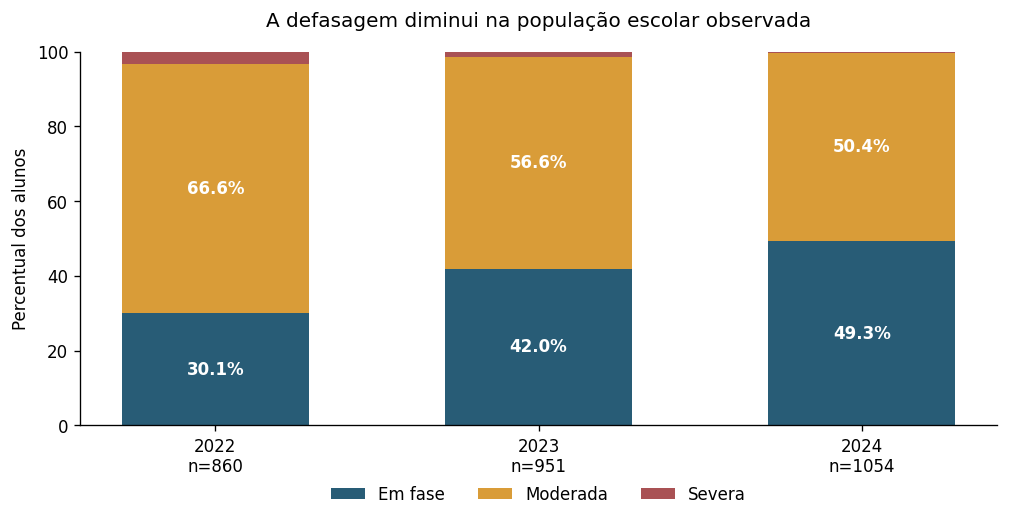

In [12]:
fig, ax = plt.subplots(figsize=(8.5, 4.5))
fundo = np.zeros(3)
for classe, cor in zip(CLASSES, CORES):
    valores = (
        defasagem_anual[
            (defasagem_anual.populacao == "Fases 0–7") & (defasagem_anual.classe == classe)
        ]
        .set_index("ano")
        .loc[ANOS, "percentual"]
        .to_numpy()
    )
    ax.bar([str(x) for x in ANOS], valores, bottom=fundo, label=classe, color=cor, width=0.58)
    for i, v in enumerate(valores):
        if v > 5:
            ax.text(
                i,
                fundo[i] + v / 2,
                f"{v:.1f}%",
                ha="center",
                va="center",
                color="white",
                fontweight="bold",
            )
    fundo += valores
ax.set(
    ylim=(0, 100),
    ylabel="Percentual dos alunos",
    xticks=range(3),
    xticklabels=[f"{ano}\nn={len(escolares[escolares['ano'].eq(ano)])}" for ano in ANOS],
)
ax.set_title("A defasagem diminui na população escolar observada", pad=15)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=3, frameon=False)
fig.tight_layout()
plt.show()
print(
    "As cores separam a situação de adequação. Cada barra soma 100% dos alunos escolares daquele ano."
)


**Resposta:** Nas fases 0–7, a defasagem passou de 69,9% (601/860) em 2022 para 58,0% (552/951) em 2023 e 50,7% (534/1.054) em 2024. Os casos severos foram 28, 14 e 3; os moderados, 573, 538 e 531. Entre os mesmos 441 alunos, a proporção caiu de 66,0% para 37,0%. Há avanço na adequação, mas metade do grupo de 2024 ainda demanda acompanhamento. A base permite comparar anos, não meses dentro do ano.

### Pergunta 2
**Pergunta:** O desempenho acadêmico médio (IDA) está melhorando, estagnado ou caindo ao longo das fases e anos?

**Gráfico:** IDA por ano e por fase de origem: evolução anual e mudança de 2022 a 2024.

In [13]:
ida_anual = (
    escolares.groupby("ano")
    .ida.agg(
        n="count",
        media="mean",
        mediana="median",
        q25=lambda s: s.quantile(0.25),
        q75=lambda s: s.quantile(0.75),
    )
    .reset_index()
)
display(ida_anual)
ida_por_fase = (
    escolares.groupby(["ano", "fase"])
    .ida.agg(n="count", media="mean", mediana="median")
    .reset_index()
)
ida_tres_anos = painel_completo("ida")
ida_painel = pd.DataFrame(
    {
        "ano": ANOS,
        "n": len(ida_tres_anos),
        "media": ida_tres_anos.mean().values,
        "mediana": ida_tres_anos.median().values,
    }
)
display(ida_painel)
fase_inicial = painel_escolar[painel_escolar["ano"].eq(2022)].set_index("ra").fase
ida_com_fase = ida_tres_anos.assign(
    fase_2022=fase_inicial, delta_22_24=ida_tres_anos[2024] - ida_tres_anos[2022]
)
mudanca_por_fase = (
    ida_com_fase.groupby("fase_2022")
    .delta_22_24.agg(n="count", media="mean", mediana="median")
    .reset_index()
)
display(mudanca_por_fase)


,ano,n,media,mediana,q25,q75
0,2022,860,6.093,6.300,4.800,7.600
1,2023,937,6.663,6.800,5.700,7.900
2,2024,1054,6.350,6.750,4.875,8.000


,ano,n,media,mediana
0,2022,435,6.678,7.000
1,2023,435,6.769,6.800
2,2024,435,6.207,6.500


,fase_2022,n,media,mediana
0,0,117,-1.008,-0.800
1,1,119,-0.935,-1.000
2,2,82,-0.214,0.000
3,3,66,0.577,0.750
4,4,33,-0.155,0.167
5,5,18,0.494,0.333


As linhas comparam médias anuais com as dos mesmos alunos. As barras mostram a mudança por fase de 2022: abaixo de zero significa queda.


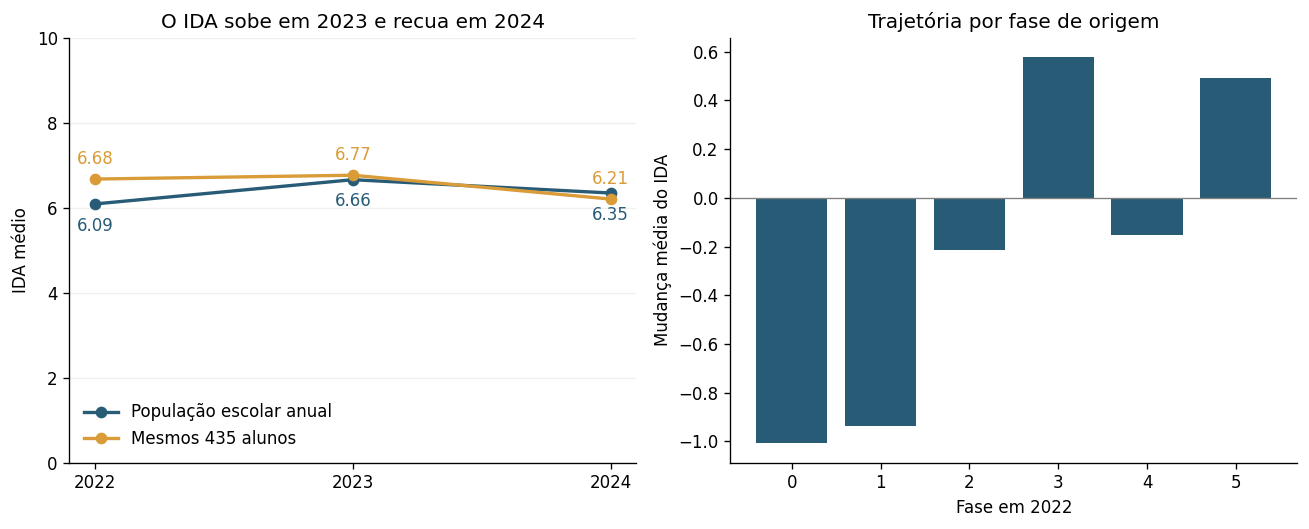

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
ax = axes[0]
for dados, label, cor in [
    (ida_anual, "População escolar anual", CORES[0]),
    (ida_painel, "Mesmos 435 alunos", CORES[1]),
]:
    ax.plot(dados.ano, dados.media, marker="o", linewidth=2, color=cor, label=label)
    for ano, v in zip(dados.ano, dados.media):
        ax.annotate(
            f"{v:.2f}",
            (ano, v),
            xytext=(0, 9 if label.startswith("Mesmos") else -16),
            textcoords="offset points",
            ha="center",
            color=cor,
        )
ax.set(xticks=ANOS, ylim=(0, 10), ylabel="IDA médio", title="O IDA sobe em 2023 e recua em 2024")
ax.legend(frameon=False, loc="lower left")
ax.grid(axis="y", alpha=0.18)
axes[1].bar(mudanca_por_fase.fase_2022.astype(str), mudanca_por_fase.media, color=CORES[0])
axes[1].axhline(0, color="gray", linewidth=0.8)
axes[1].set(
    xlabel="Fase em 2022", ylabel="Mudança média do IDA", title="Trajetória por fase de origem"
)
fig.tight_layout()
plt.show()
print(
    "As linhas comparam médias anuais com as dos mesmos alunos. As barras mostram a mudança por fase de 2022: abaixo de zero significa queda."
)


**Resposta:** O IDA médio foi 6,09 → 6,66 → 6,35. Entre os mesmos 435 alunos com notas nos três anos, foi 6,68 → 6,77 → 6,21. Não há melhora contínua. Quem estava nas fases 0 e 1 em 2022 teve queda média de 1,01 e 0,94 ponto; nas fases 3 e 5, houve aumento de 0,58 e 0,49. Vale investigar as dificuldades e os critérios de avaliação de 2024. As provas podem mudar entre fases.

### Pergunta 3
**Pergunta:** O grau de engajamento dos alunos (IEG) tem relação direta com seus indicadores de desempenho (IDA) e do ponto de virada (IPV)?

**Gráfico:** Engajamento e resultados: dispersões de IEG com IDA e IPV em 2024; tabela das associações nos três anos.

In [15]:
associacoes_engajamento = []
for ano, grupo in escolares.groupby("ano"):
    for destino in ["ida", "ipv"]:
        associacoes_engajamento.append(
            {"ano": ano, "par": f"IEG–{destino.upper()}", **correlacao(grupo, "ieg", destino)}
        )
correlacoes_engajamento = pd.DataFrame(associacoes_engajamento)
display(correlacoes_engajamento)
grupo = escolares[escolares["ano"].eq(2024)]


,ano,par,n,rho
0,2022,IEG–IDA,860,0.507
1,2022,IEG–IPV,860,0.540
2,2023,IEG–IDA,937,0.446
3,2023,IEG–IPV,938,0.492
4,2024,IEG–IDA,1054,0.519
5,2024,IEG–IPV,1054,0.551


Cada ponto é um aluno de 2024. À direita, maior engajamento; mais acima, maior desempenho ou ponto de virada.


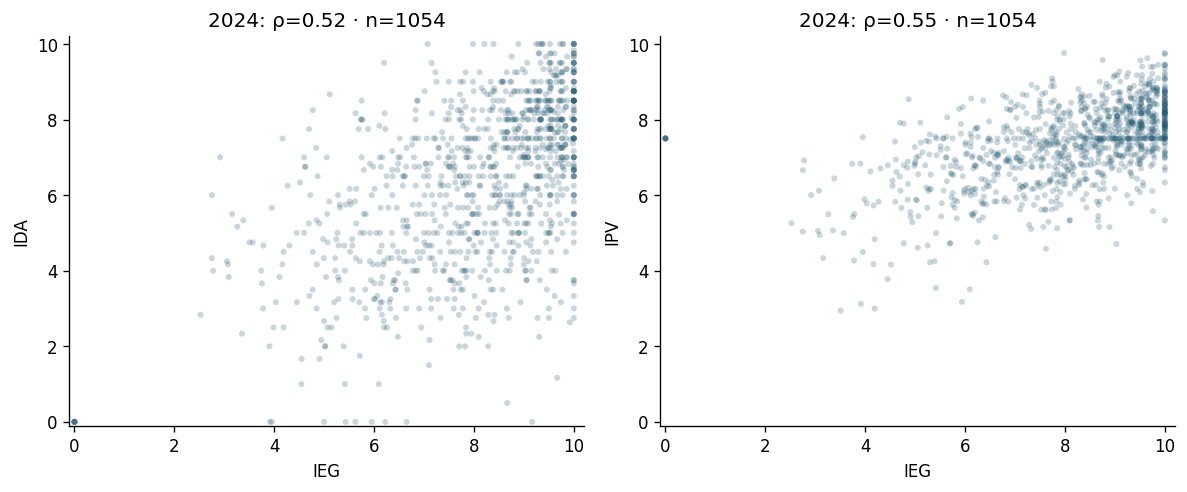

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
for ax, y in zip(axes, ["ida", "ipv"]):
    pares = grupo[["ieg", y]].dropna()
    r = correlacao(pares, "ieg", y)
    ax.scatter(pares["ieg"], pares[y], s=13, alpha=0.25, color=CORES[0], edgecolors="none")
    ax.set(
        xlim=(-0.1, 10.2),
        ylim=(-0.1, 10.2),
        xlabel="IEG",
        ylabel=y.upper(),
        title=f"2024: ρ={r['rho']:.2f} · n={r['n']}",
    )
fig.tight_layout()
plt.show()
print(
    "Cada ponto é um aluno de 2024. À direita, maior engajamento; mais acima, maior desempenho ou ponto de virada."
)


**Resposta:** Sim, há associação positiva no mesmo ano: IEG–IDA apresenta correlações de 0,51; 0,45; 0,52, e IEG–IPV de 0,54; 0,49; 0,55. Alunos mais engajados tendem a ter avaliações maiores nessas dimensões. Isso apoia o acompanhamento conjunto, mas não prova que aumentar o engajamento cause melhora ou reduza o risco futuro.

### Pergunta 4
**Pergunta:** As percepções dos alunos sobre si mesmos (IAA) são coerentes com seu desempenho real (IDA) e engajamento (IEG)?

**Gráfico:** Autoavaliação e outras avaliações: dispersões de IAA com IDA e IEG; tabela de sensibilidade aos zeros.

In [17]:
associacoes_autoavaliacao = []
resumo_autoavaliacao = []
for ano, grupo in escolares.groupby("ano"):
    resumo_autoavaliacao.append(
        {
            "ano": ano,
            "n_iaa": grupo["iaa"].count(),
            "zeros_iaa": int(grupo["iaa"].eq(0).sum()),
            "media_iaa": grupo["iaa"].mean(),
            "media_iaa_sem_zeros": grupo.loc[grupo["iaa"].gt(0), "iaa"].mean(),
        }
    )
    for destino in ["ida", "ieg"]:
        for modo in ["Observados", "IAA sem zeros"]:
            pares = grupo if modo == "Observados" else grupo[grupo["iaa"].gt(0)]
            pares = pares[["iaa", destino]].dropna()
            associacoes_autoavaliacao.append(
                {
                    "ano": ano,
                    "par": f"IAA–{destino.upper()}",
                    "analise": modo,
                    **correlacao(pares, "iaa", destino),
                    "diferenca_media": (pares["iaa"] - pares[destino]).mean(),
                    "diferenca_mediana": (pares["iaa"] - pares[destino]).median(),
                }
            )
correlacoes_autoavaliacao = pd.DataFrame(associacoes_autoavaliacao)
display(correlacoes_autoavaliacao)
resumo_autoavaliacao = pd.DataFrame(resumo_autoavaliacao)
display(resumo_autoavaliacao)


,ano,par,analise,n,rho,diferenca_media,diferenca_mediana
0,2022,IAA–IDA,Observados,860,0.183,2.182,2.200
1,2022,IAA–IDA,IAA sem zeros,821,0.142,2.503,2.300
2,2022,IAA–IEG,Observados,860,0.234,0.383,0.400
3,2022,IAA–IEG,IAA sem zeros,821,0.164,0.678,0.400
4,2023,IAA–IDA,Observados,937,0.127,0.255,1.200
5,2023,IAA–IDA,IAA sem zeros,751,0.108,1.905,1.800
6,2023,IAA–IEG,Observados,938,0.191,-1.788,-0.500
7,2023,IAA–IEG,IAA sem zeros,751,0.131,-0.147,-0.200
8,2024,IAA–IDA,Observados,1054,0.178,2.194,2.002
9,2024,IAA–IDA,IAA sem zeros,1034,0.148,2.311,2.002


,ano,n_iaa,zeros_iaa,media_iaa,media_iaa_sem_zeros
0,2022,860,39,8.274,8.667
1,2023,951,190,6.903,8.627
2,2024,1054,20,8.544,8.709


Cada ponto é um aluno de 2024. À direita, maior autoavaliação; mais acima, maior desempenho ou engajamento.


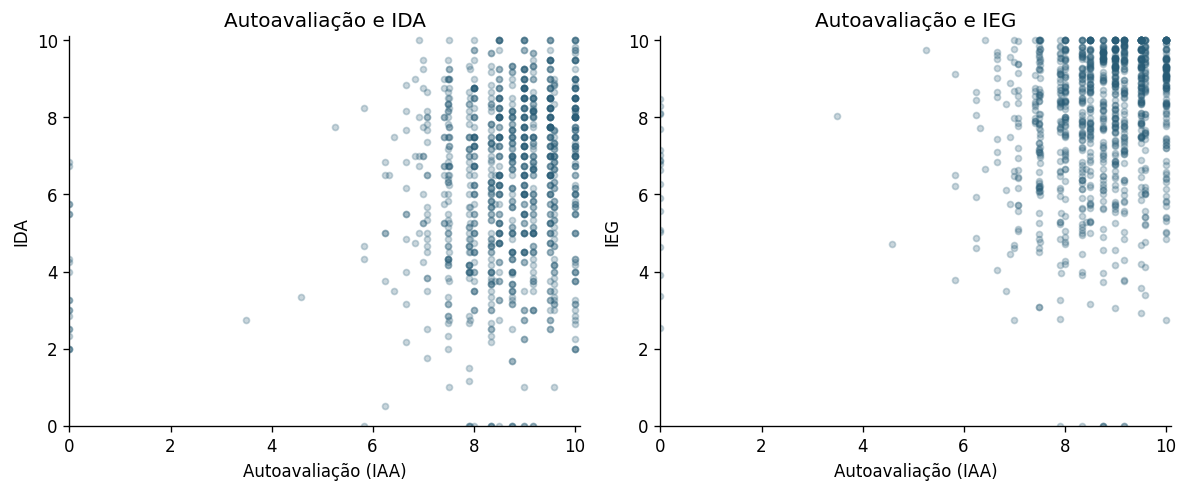

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
grupo = escolares[escolares["ano"].eq(2024)]
for ax, y in zip(axes, ["ida", "ieg"]):
    pares = grupo[["iaa", y]].dropna()
    ax.scatter(pares["iaa"], pares[y], s=13, alpha=0.25, color=CORES[0])
    ax.set(
        xlabel="Autoavaliação (IAA)",
        ylabel=y.upper(),
        xlim=(0, 10.1),
        ylim=(0, 10.1),
        title="Autoavaliação e " + y.upper(),
    )
fig.tight_layout()
plt.show()
print(
    "Cada ponto é um aluno de 2024. À direita, maior autoavaliação; mais acima, maior desempenho ou engajamento."
)


**Resposta:** A correspondência é fraca: as correlações ficam aproximadamente entre 0,13 e 0,23. Em 2023, há 190 autoavaliações iguais a zero; a média muda de 6,90 para 8,63 quando esses registros são retirados apenas para comparação. IAA traz uma perspectiva complementar, que pode orientar conversas. É necessário esclarecer o significado dos zeros antes de concluir que a autopercepção piorou.

### Pergunta 5
**Pergunta:** Há padrões psicossociais (IPS) que antecedem quedas de desempenho acadêmico ou de engajamento?

**Gráfico:** IPS anterior e quedas: percentual de alunos com queda de IDA ou IEG por faixa de IPS, nas duas transições.

In [19]:
associacoes_ips = []
faixas_ips = []
for ano, grupo in pares_escolares.groupby("ano_inicio"):
    for destino in ["ida", "ieg"]:
        pares = (
            grupo[["ra", "ips_inicio", destino + "_inicio", destino + "_fim", "delta_" + destino]]
            .dropna()
            .copy()
        )
        associacoes_ips.append(
            {
                "origem": ano,
                "desfecho": f"delta_{destino}",
                **correlacao(pares, "ips_inicio", "delta_" + destino),
                "quedas_maiores_01": int(pares["delta_" + destino].lt(-0.1 - 1e-09).sum()),
                "pct_queda_01": 100 * pares["delta_" + destino].lt(-0.1 - 1e-09).mean(),
                "pct_qualquer_queda": 100 * pares["delta_" + destino].lt(-1e-09).mean(),
            }
        )
        pares["faixa_ips"] = pd.qcut(pares.ips_inicio, 4, duplicates="drop")
        for faixa, faixa_dados in pares.groupby("faixa_ips", observed=True):
            faixas_ips.append(
                {
                    "origem": ano,
                    "desfecho": destino,
                    "faixa_ips": str(faixa),
                    "ips_min": faixa_dados.ips_inicio.min(),
                    "ips_max": faixa_dados.ips_inicio.max(),
                    "n": len(faixa_dados),
                    "quedas": int(faixa_dados["delta_" + destino].lt(-0.1 - 1e-09).sum()),
                    "pct_queda": 100 * faixa_dados["delta_" + destino].lt(-0.1 - 1e-09).mean(),
                }
            )
correlacoes_ips = pd.DataFrame(associacoes_ips)
display(correlacoes_ips)
faixas_ips = pd.DataFrame(faixas_ips)
display(faixas_ips)


,origem,desfecho,n,rho,quedas_maiores_01,pct_queda_01,pct_qualquer_queda
0,2022,delta_ida,574,0.029,267,46.516,49.652
1,2022,delta_ieg,574,-0.024,175,30.488,37.108
2,2023,delta_ida,678,0.027,368,54.277,57.080
3,2023,delta_ieg,678,0.034,417,61.504,66.224


,origem,desfecho,faixa_ips,ips_min,ips_max,n,quedas,pct_queda
0,2022,ida,"(2.499, 5.6]",2.500,5.600,148,76,51.351
1,2022,ida,"(5.6, 7.5]",6.300,7.500,395,175,44.304
2,2022,ida,"(7.5, 9.4]",8.100,9.400,31,16,51.613
3,2022,ieg,"(2.499, 5.6]",2.500,5.600,148,42,28.378
4,2022,ieg,"(5.6, 7.5]",6.300,7.500,395,126,31.899
5,2022,ieg,"(7.5, 9.4]",8.100,9.400,31,7,22.581
6,2023,ida,"(2.519, 5.0]",2.520,5.000,349,187,53.582
7,2023,ida,"(5.0, 7.52]",5.020,7.520,322,179,55.590
8,2023,ida,"(7.52, 9.38]",8.130,9.380,7,2,28.571
9,2023,ieg,"(2.519, 5.0]",2.520,5.000,349,220,63.037


Cada barra mostra a parcela de alunos que perdeu mais de 0,1 ponto no ano seguinte. n indica o tamanho do grupo inicial com as duas avaliações.


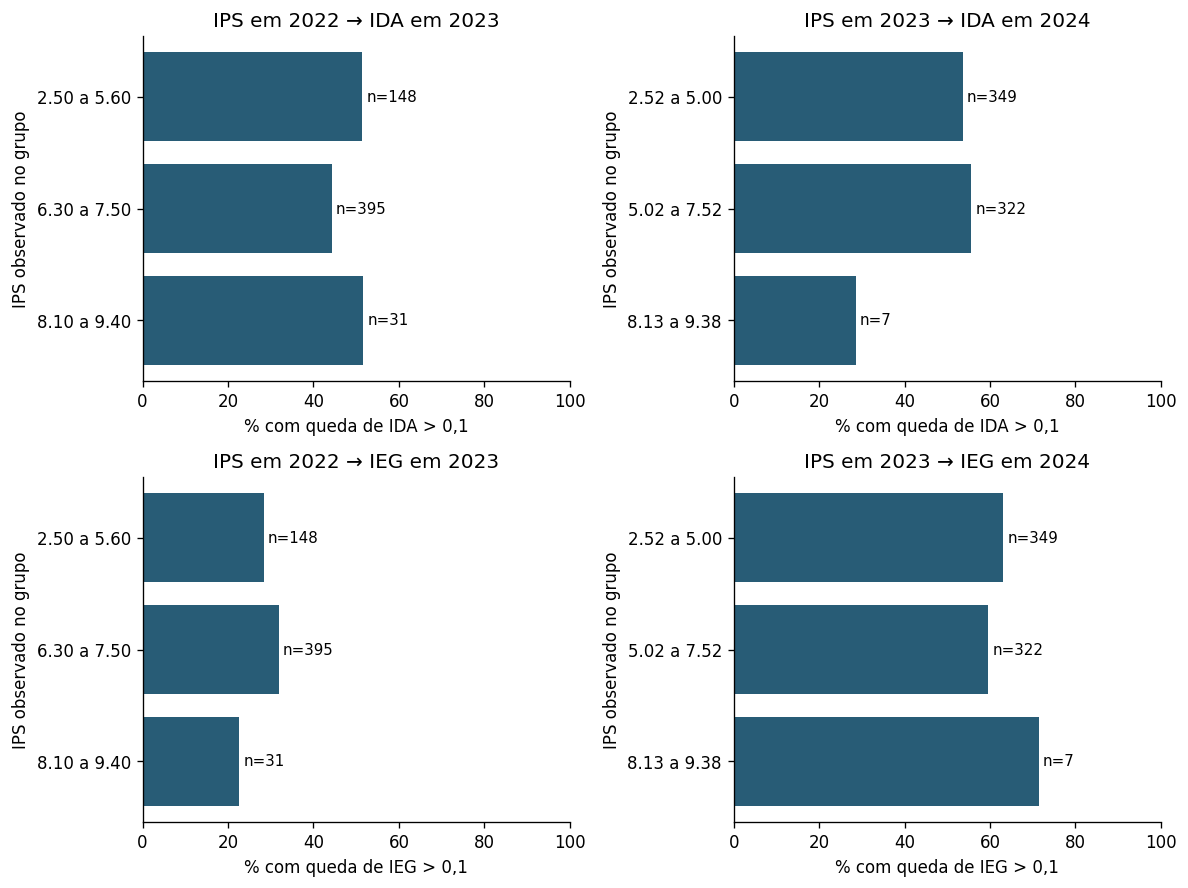

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(10, 7.5))
for ax, (ano, destino) in zip(
    axes.flat, [(2022, "ida"), (2023, "ida"), (2022, "ieg"), (2023, "ieg")]
):
    pares = faixas_ips[(faixas_ips.origem == ano) & (faixas_ips.desfecho == destino)]
    rotulos = [f"{a:.2f} a {b:.2f}" for a, b in zip(pares.ips_min, pares.ips_max)]
    ax.barh(rotulos, pares.pct_queda, color=CORES[0])
    ax.invert_yaxis()
    for i, (_, r) in enumerate(pares.iterrows()):
        ax.text(r.pct_queda + 1, i, f"n={r.n}", va="center", fontsize=9)
    ax.set(
        xlim=(0, 100),
        xlabel=f"% com queda de {destino.upper()} > 0,1",
        ylabel="IPS observado no grupo",
        title=f"IPS em {ano} → {destino.upper()} em {ano + 1}",
    )
fig.tight_layout()
plt.show()
print(
    "Cada barra mostra a parcela de alunos que perdeu mais de 0,1 ponto no ano seguinte. n indica o tamanho do grupo inicial com as duas avaliações."
)


**Resposta:** Não apareceu um padrão consistente. A associação do IPS anterior com a mudança de IDA foi próxima de 0,03 nas duas transições; com a mudança de IEG, −0,02 e +0,03. Queda foi definida como redução superior a 0,1 ponto, também comparada com qualquer redução. O IPS isolado não sustenta um alerta antecipado nesta base. Isso não reduz a importância do apoio psicossocial; sua comparabilidade entre anos continua incerta.

### Pergunta 6
**Pergunta:** As avaliações psicopedagógicas (IPP) confirmam ou contradizem a defasagem identificada pelo IAN?

**Gráfico:** Avaliação psicopedagógica por adequação: boxplots de IPP por grupo de defasagem em 2023 e 2024, com valores atípicos e tamanho dos grupos.

In [21]:
ipp_por_defasagem = (
    escolares[escolares["ano"].isin([2023, 2024])]
    .groupby(["ano", "classe_defasagem"])
    .ipp.agg(
        n="count",
        media="mean",
        mediana="median",
        q25=lambda s: s.quantile(0.25),
        q75=lambda s: s.quantile(0.75),
    )
    .reset_index()
)
display(ipp_por_defasagem)
correlacoes_ipp = pd.DataFrame(
    [
        {"ano": ano, **correlacao(grupo, "ipp", "ian")}
        for ano, grupo in escolares[escolares["ano"].ge(2023)].groupby("ano")
    ]
)
display(correlacoes_ipp)


,ano,classe_defasagem,n,media,mediana,q25,q75
0,2023,Em fase,388,7.665,7.812,7.292,8.281
1,2023,Moderada,536,7.505,7.500,6.875,8.125
2,2023,Severa,14,6.957,7.578,6.419,7.891
3,2024,Em fase,520,7.688,7.708,7.292,8.250
4,2024,Moderada,531,7.413,7.500,6.875,7.917
5,2024,Severa,3,7.260,7.031,6.953,7.453


,ano,n,rho
0,2023,938,0.106
1,2024,1054,0.160


A linha é a mediana; a caixa reúne os 50% centrais das notas. Pontos além das hastes são valores atípicos, não necessariamente erros. Nos grupos com menos de cinco alunos mostramos todas as notas; n é o tamanho do grupo.


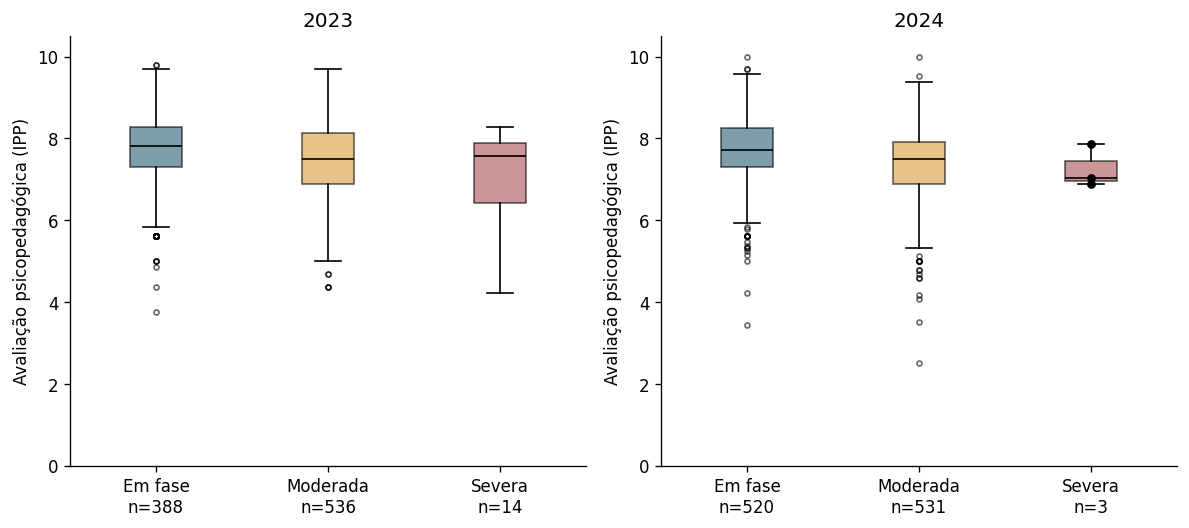

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
for ax, ano in zip(axes, [2023, 2024]):
    grupo = escolares[escolares["ano"].eq(ano)]
    valores = [
        grupo.loc[grupo["classe_defasagem"].eq(c), "ipp"].dropna().to_numpy() for c in CLASSES
    ]
    boxes = ax.boxplot(
        valores,
        patch_artist=True,
        showfliers=True,
        whis=1.5,
        tick_labels=[f"{c}\nn={len(v)}" for c, v in zip(CLASSES, valores)],
        medianprops={"color": "black"},
        flierprops={"marker": "o", "markersize": 3, "alpha": 0.6},
    )
    for box, cor in zip(boxes["boxes"], CORES):
        box.set_facecolor(cor)
        box.set_alpha(0.6)
    for pos, notas in enumerate(valores, 1):
        if len(notas) < 5:
            ax.scatter(np.full(len(notas), pos), notas, color="black", s=18, zorder=3)
    ax.set(ylim=(0, 10.5), ylabel="Avaliação psicopedagógica (IPP)", title=str(ano))
fig.tight_layout()
plt.show()
print(
    "A linha é a mediana; a caixa reúne os 50% centrais das notas. Pontos além das hastes são valores atípicos, não necessariamente erros. Nos grupos com menos de cinco alunos mostramos todas as notas; n é o tamanho do grupo."
)


**Resposta:** Há concordância fraca no conjunto, sem confirmação individual: as correlações IPP–IAN são 0,11 e 0,16. A mediana de IPP dos alunos em fase foi 7,81 e 7,71; nos moderadamente defasados, 7,50 nos dois anos. Um aluno defasado pode ter boa avaliação psicopedagógica. Os indicadores se complementam. Não há IPP em 2022 e os grupos severos são pequenos.

### Pergunta 7
**Pergunta:** Quais comportamentos — acadêmicos, emocionais ou de engajamento — mais influenciam o IPV ao longo do tempo?

**Gráfico:** Relações com o ponto de virada: associações no mesmo ano e entre indicadores anteriores e a mudança posterior de IPV.

In [23]:
associacoes_ipv = []
associacoes_ipv_futuro = []
for ano, grupo in escolares.groupby("ano"):
    for x in ["ida", "ieg", "ips", "iaa", "ipp"]:
        associacoes_ipv.append({"ano": ano, "indicador": x.upper(), **correlacao(grupo, x, "ipv")})
for ano, grupo in pares_escolares.groupby("ano_inicio"):
    for x in ["ida", "ieg", "ips", "iaa", "ipp", "ipv"]:
        associacoes_ipv_futuro.append(
            {
                "origem": ano,
                "indicador": x.upper(),
                "relacao": "Anterior × mudança de IPV",
                **correlacao(grupo, x + "_inicio", "delta_ipv"),
            }
        )
        if x != "ipv":
            associacoes_ipv_futuro.append(
                {
                    "origem": ano,
                    "indicador": x.upper(),
                    "relacao": "Mudanças simultâneas",
                    **correlacao(grupo, "delta_" + x, "delta_ipv"),
                }
            )
associacoes_ipv = pd.DataFrame(associacoes_ipv)
display(associacoes_ipv)
associacoes_ipv_futuro = pd.DataFrame(associacoes_ipv_futuro)
display(associacoes_ipv_futuro)
ordem = ["IDA", "IEG", "IPS", "IAA", "IPP"]


,ano,indicador,n,rho
0,2022,IDA,860,0.624
1,2022,IEG,860,0.540
2,2022,IPS,860,0.190
3,2022,IAA,860,0.245
4,2022,IPP,0,NaN
5,2023,IDA,937,0.551
6,2023,IEG,938,0.492
7,2023,IPS,932,0.072
8,2023,IAA,938,0.155
9,2023,IPP,938,0.512


,origem,indicador,relacao,n,rho
0,2022,IDA,Anterior × mudança de IPV,574,-0.190
1,2022,IDA,Mudanças simultâneas,574,0.317
2,2022,IEG,Anterior × mudança de IPV,574,-0.132
3,2022,IEG,Mudanças simultâneas,574,0.226
4,2022,IPS,Anterior × mudança de IPV,574,-0.016
5,2022,IPS,Mudanças simultâneas,570,0.065
6,2022,IAA,Anterior × mudança de IPV,574,-0.055
7,2022,IAA,Mudanças simultâneas,574,0.088
8,2022,IPP,Anterior × mudança de IPV,0,NaN
9,2022,IPP,Mudanças simultâneas,0,NaN


Valores positivos indicam avaliações que crescem juntas; negativos indicam direções opostas. Perto de zero há pouca associação. No segundo gráfico, a nota é anterior à mudança de IPV.


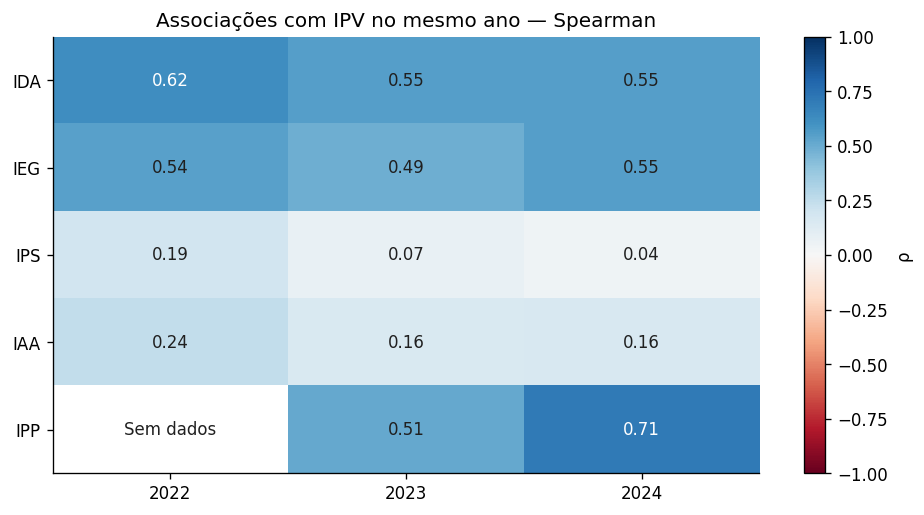

In [24]:
fig, ax = plt.subplots(figsize=(8, 4.4))
matriz = associacoes_ipv.pivot(index="indicador", columns="ano", values="rho").reindex(
    index=ordem, columns=ANOS
)
im = ax.imshow(matriz, vmin=-1, vmax=1, cmap="RdBu", aspect="auto")
for i in range(len(ordem)):
    for j in range(3):
        v = matriz.iloc[i, j]
        ax.text(
            j,
            i,
            "Sem dados" if pd.isna(v) else f"{v:.2f}",
            ha="center",
            va="center",
            color="white" if pd.notna(v) and abs(v) > 0.6 else "#202020",
        )
ax.set(
    xticks=range(3),
    xticklabels=ANOS,
    yticks=range(5),
    yticklabels=ordem,
    title="Associações com IPV no mesmo ano — Spearman",
)
fig.colorbar(im, ax=ax, label="ρ")
fig.tight_layout()
plt.show()
print(
    "Valores positivos indicam avaliações que crescem juntas; negativos indicam direções opostas. Perto de zero há pouca associação. No segundo gráfico, a nota é anterior à mudança de IPV."
)


Valores positivos indicam avaliações que crescem juntas; negativos indicam direções opostas. Perto de zero há pouca associação. No segundo gráfico, a nota é anterior à mudança de IPV.


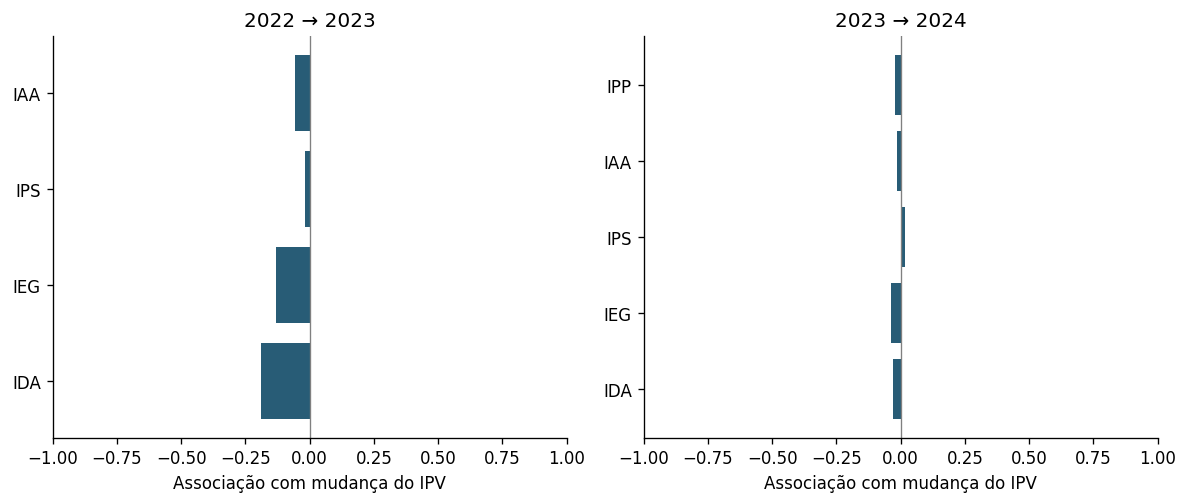

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.3))
for ax, ano in zip(axes, [2022, 2023]):
    grupo = associacoes_ipv_futuro[
        (associacoes_ipv_futuro.origem == ano)
        & (associacoes_ipv_futuro.relacao == "Anterior × mudança de IPV")
        & associacoes_ipv_futuro.indicador.ne("IPV")
    ].dropna(subset=["rho"])
    ax.barh(grupo.indicador, grupo.rho, color=CORES[0])
    ax.axvline(0, color="gray", linewidth=0.8)
    ax.set(xlim=(-1, 1), xlabel="Associação com mudança do IPV", title=f"{ano} → {ano + 1}")
fig.tight_layout()
plt.show()
print(
    "Valores positivos indicam avaliações que crescem juntas; negativos indicam direções opostas. Perto de zero há pouca associação. No segundo gráfico, a nota é anterior à mudança de IPV."
)


**Resposta:** Em 2024, IPP teve a maior associação com IPV (0,71), seguido de IEG e IDA, próximos de 0,55. Mudanças de IDA acompanharam mudanças de IPV com correlações de 0,32 e 0,40; para IEG, 0,23 e 0,28. Porém, os indicadores anteriores não anteciparam a mudança de IPV de forma estável nas duas transições. Os dados apontam dimensões para acompanhar em conjunto, sem demonstrar influência causal.

### Pergunta 8
**Pergunta:** Quais combinações de indicadores (IDA + IEG + IPS + IPP) elevam mais a nota global do aluno (INDE)?

**Gráfico:** Composição do INDE e perfis conjuntos: contribuição dos componentes e maiores médias por combinação, com pelo menos 20 alunos.

In [26]:
PESOS = {"ian": 0.1, "ida": 0.2, "ieg": 0.2, "iaa": 0.1, "ips": 0.1, "ipp": 0.1, "ipv": 0.2}
perfis_inde_linhas = []
medianas_indicadores = []
contribuicoes_inde = []
conferencia_inde = []
for ano in [2023, 2024]:
    grupo = escolares[escolares["ano"].eq(ano)].dropna(subset=list(PESOS) + ["inde"]).copy()
    calc = sum((grupo[c] * p for c, p in PESOS.items()))
    conferencia_inde.append(
        {
            "ano": ano,
            "n": len(grupo),
            "erro_absoluto_medio": (calc - grupo["inde"]).abs().mean(),
            "erro_maximo": (calc - grupo["inde"]).abs().max(),
        }
    )
    for c, peso in PESOS.items():
        contribuicoes_inde.append(
            {
                "ano": ano,
                "indicador": c.upper(),
                "peso": peso,
                "contribuicao_media": (grupo[c] * peso).mean(),
            }
        )
    chaves = ["ida", "ieg", "ips", "ipp"]
    limites = grupo[chaves].median()
    for c in chaves:
        medianas_indicadores.append({"ano": ano, "indicador": c.upper(), "mediana": limites[c]})
    grupo["perfil"] = grupo.apply(
        lambda r: " | ".join(
            (f"{c.upper()} {('alto' if r[c] >= limites[c] else 'baixo')}" for c in chaves)
        ),
        axis=1,
    )
    for perfil, pares in grupo.groupby("perfil"):
        perfis_inde_linhas.append(
            {
                "ano": ano,
                "perfil": perfil,
                "n": len(pares),
                "inde_medio": pares["inde"].mean(),
                "inde_mediano": pares["inde"].median(),
            }
        )
perfis_inde = pd.DataFrame(perfis_inde_linhas).sort_values(
    ["ano", "inde_medio"], ascending=[True, False]
)
display(pd.DataFrame(medianas_indicadores))
display(pd.DataFrame(conferencia_inde))
contribuicoes_inde = pd.DataFrame(contribuicoes_inde)
display(contribuicoes_inde)
print("Perfis com maior INDE médio e n ≥ 20 por ano:")
display(perfis_inde[perfis_inde.n.ge(20)].groupby("ano").head(3).round(3))


Perfis com maior INDE médio e n ≥ 20 por ano:


,ano,indicador,mediana
0,2023,IDA,6.800
1,2023,IEG,9.000
2,2023,IPS,5.000
3,2023,IPP,7.656
4,2024,IDA,6.750
5,2024,IEG,8.592
6,2024,IPS,7.510
7,2024,IPP,7.500


,ano,n,erro_absoluto_medio,erro_maximo
0,2023,931,0.005,0.015
1,2024,1054,0.000,0.000


,ano,indicador,peso,contribuicao_media
0,2023,IAN,0.100,0.704
1,2023,IDA,0.200,1.334
2,2023,IEG,0.200,1.740
3,2023,IAA,0.100,0.691
4,2023,IPS,0.100,0.513
5,2023,IPP,0.100,0.756
6,2023,IPV,0.200,1.607
7,2024,IAN,0.100,0.746
8,2024,IDA,0.200,1.270
9,2024,IEG,0.200,1.618


,ano,perfil,n,inde_medio,inde_mediano
1,2023,IDA alto | IEG alto | IPS alto | IPP baixo,79,8.252,8.285
0,2023,IDA alto | IEG alto | IPS alto | IPP alto,107,8.207,8.228
2,2023,IDA alto | IEG alto | IPS baixo | IPP alto,87,7.917,7.935
16,2024,IDA alto | IEG alto | IPS alto | IPP alto,193,8.404,8.397
18,2024,IDA alto | IEG alto | IPS baixo | IPP alto,128,8.320,8.279
17,2024,IDA alto | IEG alto | IPS alto | IPP baixo,26,7.892,7.896


O primeiro gráfico mostra parcelas da nota global. No segundo, alto significa igual ou acima da mediana anual, baixo significa abaixo. As médias não isolam efeitos de intervenções.


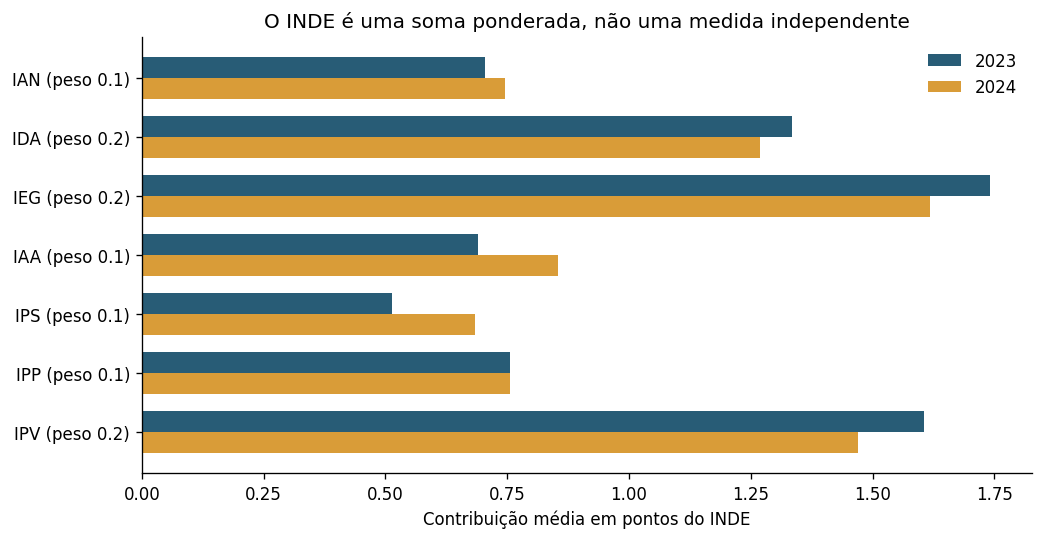

In [27]:
fig, ax = plt.subplots(figsize=(8.8, 4.6))
ordem = list(PESOS)
pos = np.arange(7)
for ano, deslocamento, cor in [(2023, -0.18, CORES[0]), (2024, 0.18, CORES[1])]:
    grupo = (
        contribuicoes_inde[contribuicoes_inde.ano.eq(ano)]
        .set_index("indicador")
        .reindex([c.upper() for c in ordem])
    )
    ax.barh(pos + deslocamento, grupo.contribuicao_media, height=0.36, label=str(ano), color=cor)
ax.set(
    yticks=pos,
    yticklabels=[f"{c.upper()} (peso {PESOS[c]:.1f})" for c in ordem],
    xlabel="Contribuição média em pontos do INDE",
    title="O INDE é uma soma ponderada, não uma medida independente",
)
ax.invert_yaxis()
ax.legend(frameon=False)
fig.tight_layout()
plt.show()
print(
    "O primeiro gráfico mostra parcelas da nota global. No segundo, alto significa igual ou acima da mediana anual, baixo significa abaixo. As médias não isolam efeitos de intervenções."
)


O primeiro gráfico mostra parcelas da nota global. No segundo, alto significa igual ou acima da mediana anual, baixo significa abaixo. As médias não isolam efeitos de intervenções.


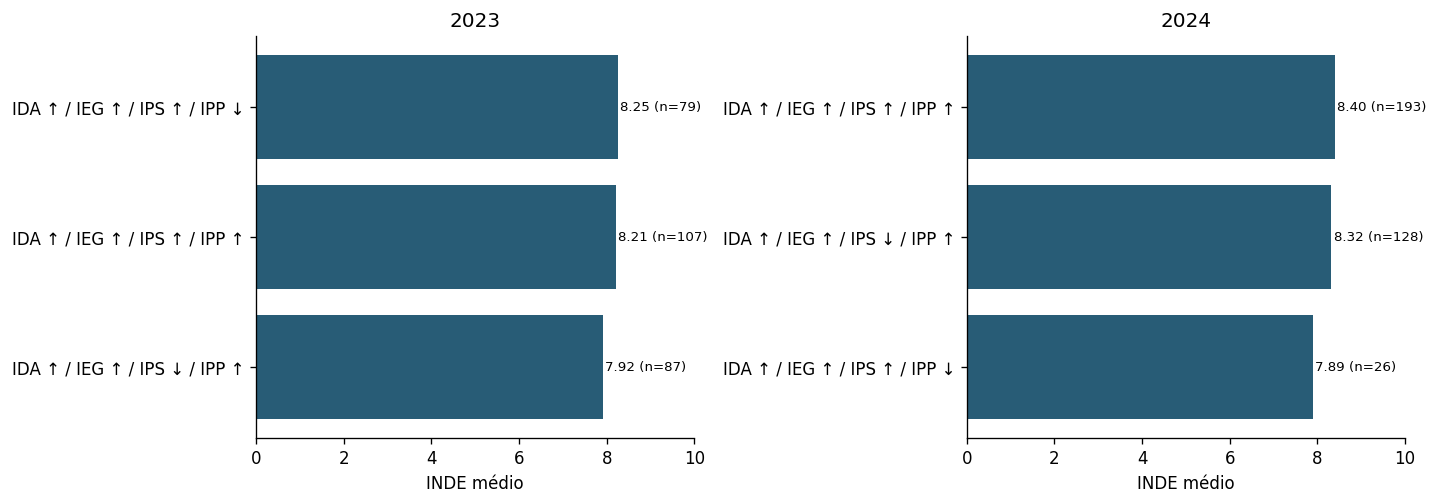

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.3))
for ax, ano in zip(axes, [2023, 2024]):
    grupo = perfis_inde[perfis_inde.ano.eq(ano) & perfis_inde.n.ge(20)].head(3)
    rotulos = (
        grupo.perfil.str.replace(" | ", " / ", regex=False)
        .str.replace("alto", "↑")
        .str.replace("baixo", "↓")
    )
    ax.barh(rotulos, grupo.inde_medio, color=CORES[0])
    ax.invert_yaxis()
    for i, r in enumerate(grupo.itertuples()):
        ax.text(r.inde_medio + 0.05, i, f"{r.inde_medio:.2f} (n={r.n})", va="center", fontsize=8)
    ax.set(xlim=(0, 10), xlabel="INDE médio", title=str(ano))
fig.tight_layout()
plt.show()
print(
    "O primeiro gráfico mostra parcelas da nota global. No segundo, alto significa igual ou acima da mediana anual, baixo significa abaixo. As médias não isolam efeitos de intervenções."
)


**Resposta:** IDA e IEG têm peso de 20% cada; IPS e IPP, 10% cada. Pela fórmula, aumentar um ponto nos quatro acrescenta 0,6 ao INDE, mantendo os demais componentes fixos. Em 2024, o perfil com os quatro indicadores na mediana ou acima teve média 8,40 (193 alunos). Em 2023, a maior média entre perfis com pelo menos 20 alunos foi 8,25: IDA/IEG/IPS altos e IPP baixo (79 alunos). Os outros componentes também variam, portanto esse resultado não indica benefício em reduzir IPP.

### Comparabilidade dos indicadores
O IPS apresenta distribuições diferentes entre anos. Em 2022, 406 registros têm recomendação “Não atendido”, com IPS próximo de 7,5. Nos anos seguintes, a recomendação não foi preenchida. Os materiais não confirmam equivalência dos critérios entre anos; por isso o IPS permanece na análise, mas não no modelo final.

In [29]:
display(escolares.groupby("ano")["ips"].agg(["count", "mean", "median", "nunique"]))
display(brutas["PEDE2022"].groupby("Rec Psicologia")["IPS"].agg(["count", "mean", "min", "max"]))
print(
    "Recomendações preenchidas:",
    {ano: int(brutas[f"PEDE{ano}"]["Rec Psicologia"].notna().sum()) for ano in ANOS},
)


Recomendações preenchidas: {2022: 860, 2023: 0, 2024: 0}


,count,mean,median,nunique
ano,,,,
2022,860,6.905,7.500,12
2023,945,5.120,5.000,21
2024,1054,6.830,7.510,38


,count,mean,min,max
Rec Psicologia,,,,
Não atendido,406,7.496,5.000,8.800
Não avaliado,5,7.500,7.500,7.500
Não indicado,37,5.086,3.800,7.500
Requer avaliação,158,5.529,2.500,8.800
Sem limitações,254,7.069,4.400,10.000


## 6. Engenharia de variáveis e separação temporal
A fase foi transformada em número, o RA ligou os anos e o alvo indica **defasagem negativa no ano seguinte**. Só entram alunos inicialmente sem defasagem, nas fases 0–6, com desfecho conhecido em fase 0–7. Ausência de acompanhamento não significa ausência de risco.

Desenvolvimento: 2022 → 2023. Avaliação posterior: 2023 → 2024. Não exigimos presença nos três anos para o modelo, pois isso excluiria alunos sem necessidade.

In [30]:
FEATURES = ["ida", "ieg", "ipv", "fase"]
CAMPOS_COORTE = ["ra", "ano", "ida", "ieg", "ips", "ipv", "fase", "idade", "alvo"]
coortes = {}
fluxos = []
for ano in [2022, 2023]:
    inicio = alunos_ano[alunos_ano["ano"].eq(ano)]
    elegiveis = inicio[inicio["fase"].between(0, 6) & inicio["defasagem"].ge(0)]
    futuro = alunos_ano[alunos_ano["ano"].eq(ano + 1)][["ra", "fase", "fase_ideal", "defasagem"]]
    futuro = futuro.rename(
        columns={
            "fase": "fase_futura",
            "fase_ideal": "fase_ideal_futura",
            "defasagem": "defasagem_futura",
        }
    )
    unidos = elegiveis.merge(futuro, on="ra", how="left", validate="one_to_one", indicator=True)
    valido = unidos["fase_futura"].between(0, 7) & unidos["defasagem_futura"].notna()
    observados = unidos[valido].copy()
    assert observados["defasagem"].eq(observados["fase"] - observados["fase_ideal"]).all()
    assert (
        observados["defasagem_futura"]
        .eq(observados["fase_futura"] - observados["fase_ideal_futura"])
        .all()
    )
    observados["alvo"] = observados["defasagem_futura"].lt(0).astype(int)
    coortes[ano] = observados[CAMPOS_COORTE].sort_values("ra").reset_index(drop=True)
    fluxos.append(
        {
            "Ano dos indicadores": ano,
            "Elegíveis": len(elegiveis),
            "Sem acompanhamento": int(unidos["_merge"].eq("left_only").sum()),
            "Outros sem desfecho válido": int((unidos["_merge"].eq("both") & ~valido).sum()),
            "Alunos na avaliação": len(observados),
            "Novos casos": int(observados["alvo"].sum()),
        }
    )
display(pd.DataFrame(fluxos))


,Ano dos indicadores,Elegíveis,Sem acompanhamento,Outros sem desfecho válido,Alunos na avaliação,Novos casos
0,2022,254,68,0,186,60
1,2023,382,86,0,296,84


In [31]:
dev = coortes[2022]
teste = coortes[2023]
X, y_dev = (dev[FEATURES], dev["alvo"].to_numpy())
X_teste, y_teste = (teste[FEATURES], teste["alvo"].to_numpy())
assert not X.isna().any().any() and (not X_teste.isna().any().any())
print("Alunos presentes nos dois períodos:", len(set(dev["ra"]) & set(teste["ra"])))
display(dev[FEATURES].agg(["min", "max"]))


Alunos presentes nos dois períodos: 98


,ida,ieg,ipv,fase
min,2.000,4.600,5.056,0
max,9.900,10.000,9.750,6


**Resultado:** 186 alunos e 60 casos no desenvolvimento; 296 alunos e 84 casos na avaliação posterior. Há 98 alunos nos dois períodos, com avaliações anuais distintas. Portanto, a avaliação mede um período posterior, não uma população inteiramente nova. Não há preenchimento de entradas ausentes nessas coortes.

**Escolha das entradas:** usamos IDA, IEG, IPV e fase. IPS saiu por comparabilidade incerta, e idade pela correlação de 0,972 com fase. IPP está ausente em 2022; IAA tem zeros ambíguos; INDE combina outros indicadores. Para uso real, todos os indicadores, inclusive IPV, precisam estar disponíveis no momento da previsão.

**Histórico:** o modelo original usava seis entradas e identificou 24 casos, com 10 falsos alertas e recall de 28,6%. A revisão ocorreu depois de observar 2024. Os resultados finais não representam um novo teste independente.

### Pergunta 9
**Pergunta:** Quais padrões nos indicadores permitem identificar alunos em risco antes de queda no desempenho ou aumento da defasagem? Construa um modelo preditivo que mostre uma probabilidade do aluno ou aluna entrar em risco de defasagem.

**Gráfico:** Resultados da previsão: matriz de acertos e erros no corte de 27,8%, curva de precisão e identificação de casos e pesos do modelo.

## 7. Comparação de três modelos
As mesmas cinco divisões estratificadas do desenvolvimento são usadas nos três modelos. A padronização da Regressão Logística é ajustada apenas dentro do treino de cada divisão. Nenhuma alternativa é escolhida por resultados de 2024.

In [32]:
particoes = list(StratifiedKFold(n_splits=5, shuffle=True, random_state=42).split(X, y_dev))
modelos = {
    "Logística": Pipeline(
        [
            ("escala", StandardScaler()),
            ("modelo", LogisticRegression(C=1, solver="lbfgs", max_iter=2000, random_state=42)),
        ]
    ),
    "Árvore": DecisionTreeClassifier(max_depth=2, min_samples_leaf=10, random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=3,
        min_samples_leaf=10,
        max_features="sqrt",
        random_state=42,
        n_jobs=1,
    ),
}


### Validação e sinais de overfitting
Comparamos a AP do treino e da validação. Uma diferença grande sugere que o modelo aprendeu particularidades do treino. Brier avalia o erro das probabilidades: valores menores são melhores.

In [33]:
resultados, detalhes, pesos_particoes, previsoes_oof = ([], [], [], {})
for nome, modelo in modelos.items():
    previsoes = np.zeros(len(dev))
    ap_treino, ap_validacao = ([], [])
    for fold, (treino, validacao) in enumerate(particoes, 1):
        ajuste = clone(modelo).fit(X.iloc[treino], y_dev[treino])
        previsoes[validacao] = ajuste.predict_proba(X.iloc[validacao])[:, 1]
        ap_treino.append(
            average_precision_score(y_dev[treino], ajuste.predict_proba(X.iloc[treino])[:, 1])
        )
        ap_validacao.append(average_precision_score(y_dev[validacao], previsoes[validacao]))
        detalhes.append(
            dict(modelo=nome, fold=fold, ap_treino=ap_treino[-1], ap_validacao=ap_validacao[-1])
        )
        if nome == "Logística":
            pesos_particoes.append(ajuste.named_steps["modelo"].coef_[0])
    previsoes_oof[nome] = previsoes
    resultados.append(
        dict(
            modelo=nome,
            ap_media=float(np.mean(ap_validacao)),
            ap_dp=float(np.std(ap_validacao, ddof=1)),
            gap_ap=float(np.mean(ap_treino) - np.mean(ap_validacao)),
            ap_oof=average_precision_score(y_dev, previsoes),
            roc_auc_oof=roc_auc_score(y_dev, previsoes),
            brier_oof=brier_score_loss(y_dev, previsoes),
        )
    )
comparacao = pd.DataFrame(resultados)


In [34]:
display(
    comparacao[["modelo", "ap_media", "ap_dp", "gap_ap", "brier_oof"]]
    .rename(
        columns={
            "modelo": "Modelo",
            "ap_media": "AP média nas 5 divisões",
            "ap_dp": "Variação entre divisões",
            "gap_ap": "Diferença de AP treino–validação",
            "brier_oof": "Erro das probabilidades (Brier)",
        }
    )
    .round(3)
)
baseline_ap = float(np.mean([y_dev[va].mean() for _, va in particoes]))
print(f"Referência sem discriminação: AP média = {baseline_ap:.3f}")


Referência sem discriminação: AP média = 0.323


,Modelo,AP média nas 5 divisões,Variação entre divisões,Diferença de AP treino–validação,Erro das probabilidades (Brier)
0,Logística,0.639,0.084,-0.001,0.177
1,Árvore,0.522,0.044,0.074,0.185
2,Random Forest,0.583,0.123,0.170,0.181


A Regressão Logística teve AP média de **0,639**, contra **0,583** da Random Forest e **0,522** da árvore. A floresta apresentou diferença de **0,170** entre treino e validação, sinal de maior sobreajuste. Mantemos a Regressão Logística.

AP resume a qualidade da priorização dos casos ao variar o corte. A referência sem discriminação foi **0,323**. AP não é acurácia e não mede a qualidade exata das probabilidades.

A regra registrada antes desta comparação exigia, para substituir a Logística: ganho de 0,02 de AP média, superioridade em pelo menos 3 das 5 divisões, diferença treino–validação até 0,10 e Brier até 0,01 acima da referência. Nenhuma alternativa atingiu sequer o ganho de AP. Esta execução reproduz as configurações já avaliadas, sem nova busca de modelos.

## 8. Modelo final e avaliação temporal
O corte **0,278** transforma a probabilidade em alerta; ele não altera a probabilidade. A escolha de priorizar alertas mais assertivos foi feita após examinar os resultados anteriores. Não fazemos nova busca de cortes nesta execução.

In [35]:
def medir(y_real, probabilidade, corte):
    tn, fp, fn, tp = confusion_matrix(y_real, probabilidade >= corte, labels=[0, 1]).ravel()
    return dict(
        n=len(y_real),
        positivos=int(np.sum(y_real)),
        tp=int(tp),
        fp=int(fp),
        fn=int(fn),
        tn=int(tn),
        alertas=int(tp + fp),
        precisao=float(tp / (tp + fp)) if tp + fp else 0.0,
        recall=float(tp / (tp + fn)),
        f1=float(2 * tp / (2 * tp + fp + fn)),
        acuracia=float((tp + tn) / len(y_real)),
        ap=average_precision_score(y_real, probabilidade),
        roc_auc=roc_auc_score(y_real, probabilidade),
        brier=brier_score_loss(y_real, probabilidade),
        prob_media=float(probabilidade.mean()),
    )


In [36]:
CORTE = 0.278
CORTE_ANTERIOR = 0.21685686133388166
modelo_final = clone(modelos["Logística"]).fit(X, y_dev)
teste = coortes[2023]
yt = y_teste
probabilidades = modelo_final.predict_proba(teste[FEATURES])[:, 1]
metricas = medir(yt, probabilidades, CORTE)
metricas_anteriores = medir(yt, probabilidades, CORTE_ANTERIOR)


In [37]:
tradeoff = pd.DataFrame(
    [{"Corte": "21,7% (anterior)", **metricas_anteriores}, {"Corte": "27,8% (adotado)", **metricas}]
)
display(
    tradeoff[["Corte", "alertas", "tp", "fp", "fn", "precisao", "recall"]]
    .rename(
        columns={
            "alertas": "Alunos sinalizados",
            "tp": "Casos identificados",
            "fp": "Falsos alertas",
            "fn": "Casos sem alerta",
            "precisao": "Proporção de alertas confirmados",
            "recall": "Proporção de casos identificados",
        }
    )
    .round(3)
)


,Corte,Alunos sinalizados,Casos identificados,Falsos alertas,Casos sem alerta,Proporção de alertas confirmados,Proporção de casos identificados
0,"21,7% (anterior)",111,58,53,26,0.523,0.690
1,"27,8% (adotado)",69,44,25,40,0.638,0.524


A matriz cruza o que aconteceu com o alerta emitido. Na curva, avançar à direita identifica mais casos; a altura mostra quanto dos alertas se confirma.


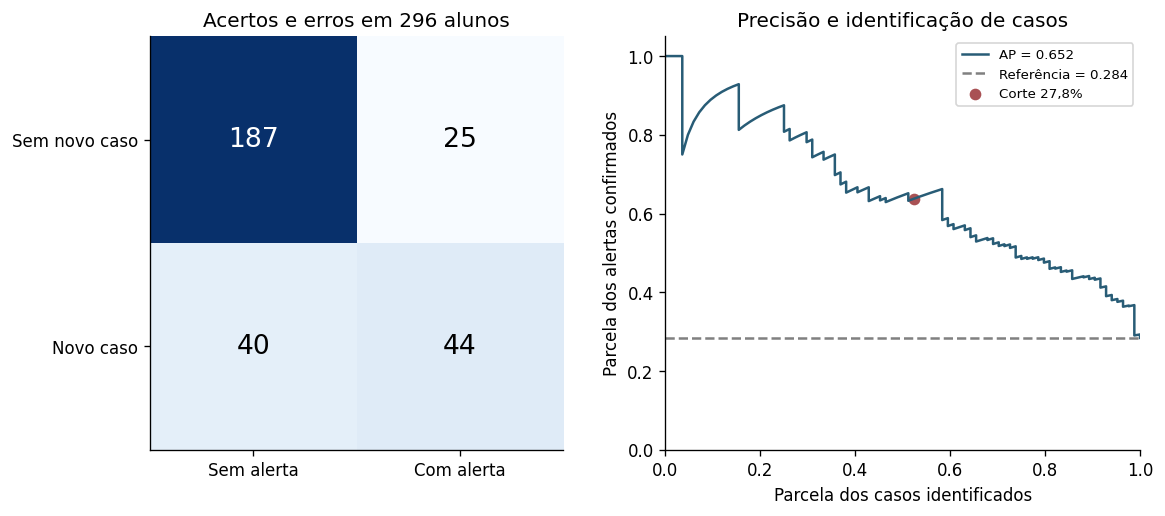

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.4))
matriz = confusion_matrix(yt, probabilidades >= CORTE, labels=[0, 1])
axes[0].imshow(matriz, cmap="Blues")
for (i, j), valor in np.ndenumerate(matriz):
    axes[0].text(
        j,
        i,
        str(valor),
        ha="center",
        va="center",
        color="white" if valor > matriz.max() / 2 else "black",
        fontsize=16,
    )
axes[0].set(
    xticks=[0, 1],
    yticks=[0, 1],
    xticklabels=["Sem alerta", "Com alerta"],
    yticklabels=["Sem novo caso", "Novo caso"],
    title="Acertos e erros em 296 alunos",
)
precisao, recall, _ = precision_recall_curve(yt, probabilidades)
axes[1].plot(recall, precisao, color=CORES[0], label=f"AP = {metricas['ap']:.3f}")
axes[1].axhline(yt.mean(), linestyle="--", color="gray", label=f"Referência = {yt.mean():.3f}")
axes[1].scatter([metricas["recall"]], [metricas["precisao"]], color=CORES[2], label="Corte 27,8%")
axes[1].set(
    xlim=(0, 1),
    ylim=(0, 1.05),
    xlabel="Parcela dos casos identificados",
    ylabel="Parcela dos alertas confirmados",
    title="Precisão e identificação de casos",
)
axes[1].legend(fontsize=8)
fig.tight_layout()
plt.show()
print(
    "A matriz cruza o que aconteceu com o alerta emitido. Na curva, avançar à direita identifica mais casos; a altura mostra quanto dos alertas se confirma."
)


In [39]:
display(
    pd.DataFrame(
        {
            "Métrica": [
                "Acurácia",
                "Equilíbrio entre precisão e recall (F1)",
                "Average Precision",
                "Área sob a curva ROC",
                "Erro das probabilidades (Brier)",
                "Probabilidade média",
                "Proporção observada de casos",
            ],
            "Resultado": [
                metricas[k] for k in ["acuracia", "f1", "ap", "roc_auc", "brier", "prob_media"]
            ]
            + [float(yt.mean())],
        }
    ).round(3)
)


,Métrica,Resultado
0,Acurácia,0.780
1,Equilíbrio entre precisão e recall (F1),0.575
2,Average Precision,0.652
3,Área sob a curva ROC,0.813
4,Erro das probabilidades (Brier),0.160
5,Probabilidade média,0.210
6,Proporção observada de casos,0.284


**Resultado:** 44 dos 69 alertas se confirmaram (**63,8% de precisão**). Foram identificados **52,4% dos casos**, e 40 dos 84 casos ficaram sem alerta. Em relação ao corte anterior, são 28 falsos alertas a menos, mas 14 casos identificados a menos.

A probabilidade média foi 21,0%, abaixo dos 28,4% observados. O corte não corrige essa subestimação. Amostra pequena, perdas de acompanhamento e uso prévio de 2024 limitam a generalização; precisamos de um novo período para avaliação independente.

## 9. Interpretação das variáveis
Os coeficientes padronizados mostram direção e magnitude das associações, mantendo as outras entradas iguais. Não representam efeito causal nem percentual de importância.

À direita, a entrada eleva o escore de risco; à esquerda, reduz. A padronização permite comparar magnitudes, mantendo as demais entradas constantes.


,Indicador,Peso padronizado,Peso por ponto
0,ida,-0.284,-0.185
1,ieg,0.386,0.349
2,ipv,-0.965,-1.101
3,fase,-0.768,-0.460


,ida,ieg,ipv,fase
min,-0.344,0.206,-1.058,-0.905
max,-0.212,0.516,-0.746,-0.684


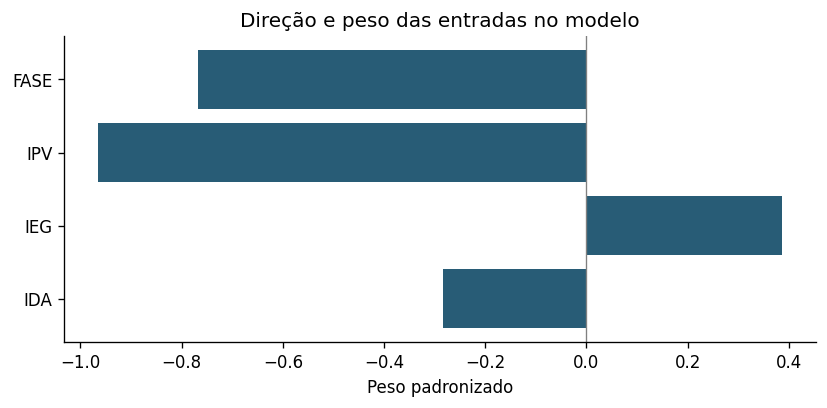

In [40]:
escala = modelo_final.named_steps["escala"]
regressao = modelo_final.named_steps["modelo"]
coeficientes = pd.DataFrame(
    {
        "Indicador": FEATURES,
        "Peso padronizado": regressao.coef_[0],
        "Peso por ponto": regressao.coef_[0] / escala.scale_,
    }
)
display(coeficientes.round(3))
display(pd.DataFrame(pesos_particoes, columns=FEATURES).agg(["min", "max"]).round(3))
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.barh(coeficientes.Indicador.str.upper(), coeficientes["Peso padronizado"], color=CORES[0])
ax.axvline(0, color="gray", linewidth=0.8)
ax.set(xlabel="Peso padronizado", title="Direção e peso das entradas no modelo")
fig.tight_layout()
plt.show()
print(
    "À direita, a entrada eleva o escore de risco; à esquerda, reduz. A padronização permite comparar magnitudes, mantendo as demais entradas constantes."
)


IPV e fase têm os maiores pesos padronizados, ambos negativos. IEG tem peso positivo neste ajuste, inclusive nas cinco divisões internas. Isso não significa que aumentar engajamento cause defasagem. As relações condicionais do modelo são diferentes das correlações entre notas no mesmo ano.

Uma nota alta de IDA não anula as demais entradas. Valores fora da faixa do desenvolvimento representam extrapolação e são sinalizados na aplicação.

**Resposta:** O modelo combina IDA, IEG, IPV e fase para prever entrada em defasagem no ano seguinte entre alunos inicialmente sem defasagem, nas fases 0–6. IPV e fase têm os maiores pesos padronizados, ambos negativos; IEG tem peso positivo neste ajuste, sem interpretação causal. No período posterior, o corte de 27,8% sinalizou 69 de 296 alunos: 44 casos confirmados e 25 falsos alertas. A precisão foi 63,8% e a identificação dos 84 casos foi 52,4%; 40 casos ficaram sem alerta. A proposta prioriza revisões mais assertivas, mantendo acompanhamento para todos. O resultado é exploratório, pois 2024 já havia sido examinado, e as probabilidades ainda subestimam o risco médio.

## 10. Evolução do programa

### Pergunta 10
**Pergunta:** Os indicadores mostram melhora consistente ao longo do ciclo nas diferentes fases (Quartzo, Ágata, Ametista e Topázio), confirmando o impacto real do programa?

**Gráfico:** Evolução dos mesmos alunos: médias dos indicadores e mudança de IDA por pedra inicial de 2022.

In [41]:
trajetorias = []
mudancas_individuais = []
mudancas_por_pedra = []
pedra_inicio = painel_escolar[painel_escolar["ano"].eq(2022)].set_index("ra").pedra
for indicador in ["defasagem", "ida", "ieg", "ipv", "inde"]:
    painel = painel_completo(indicador)
    delta = painel[2024] - painel[2022]
    tol = 0 if indicador == "defasagem" else 0.1
    for ano in ANOS:
        trajetorias.append(
            {
                "indicador": indicador.upper(),
                "ano": ano,
                "n": len(painel),
                "media": painel[ano].mean(),
                "mediana": painel[ano].median(),
            }
        )
    for limiar in sorted(set([0, tol])):
        situacao = np.select(
            [delta.gt(limiar + 1e-09), delta.lt(-limiar - 1e-09)],
            ["Melhora", "Piora"],
            default="Estável",
        )
        mudancas_individuais.append(
            {
                "indicador": indicador.upper(),
                "n": len(painel),
                "tolerancia": limiar,
                "delta_medio": delta.mean(),
                "melhora": int((situacao == "Melhora").sum()),
                "estavel": int((situacao == "Estável").sum()),
                "piora": int((situacao == "Piora").sum()),
            }
        )
    for pedra in PEDRAS:
        idx = delta.index.intersection(pedra_inicio[pedra_inicio.eq(pedra)].index)
        d = delta.loc[idx]
        mudancas_por_pedra.append(
            {
                "indicador": indicador.upper(),
                "pedra_2022": pedra,
                "n": len(d),
                "delta_medio": d.mean(),
                "pct_melhora": 100 * d.gt(tol + 1e-09).mean() if len(d) else np.nan,
            }
        )
trajetorias = pd.DataFrame(trajetorias)
display(trajetorias)
mudancas_individuais = pd.DataFrame(mudancas_individuais)
display(mudancas_individuais)
mudancas_por_pedra = pd.DataFrame(mudancas_por_pedra)
display(mudancas_por_pedra)


,indicador,ano,n,media,mediana
0,DEFASAGEM,2022,441,-0.832,-1.000
1,DEFASAGEM,2023,441,-0.685,-1.000
2,DEFASAGEM,2024,441,-0.243,0.000
3,IDA,2022,435,6.678,7.000
4,IDA,2023,435,6.769,6.800
5,IDA,2024,435,6.207,6.500
6,IEG,2022,435,8.525,8.800
7,IEG,2023,435,8.732,9.000
8,IEG,2024,435,7.949,8.381
9,IPV,2022,435,7.515,7.500


,indicador,n,tolerancia,delta_medio,melhora,estavel,piora
0,DEFASAGEM,441,0.000,0.590,251,142,48
1,IDA,435,0.000,-0.471,191,4,240
2,IDA,435,0.100,-0.471,181,21,233
3,IEG,435,0.000,-0.576,186,9,240
4,IEG,435,0.100,-0.576,170,39,226
5,IPV,435,0.000,-0.220,185,2,248
6,IPV,435,0.100,-0.220,171,35,229
7,INDE,434,0.000,-0.003,240,0,194
8,INDE,434,0.100,-0.003,213,39,182


,indicador,pedra_2022,n,delta_medio,pct_melhora
0,DEFASAGEM,Quartzo,26,0.308,42.308
1,DEFASAGEM,Ágata,108,0.389,47.222
2,DEFASAGEM,Ametista,206,0.684,62.621
3,DEFASAGEM,Topázio,101,0.683,59.406
4,IDA,Quartzo,26,1.911,88.462
5,IDA,Ágata,108,-0.191,45.370
6,IDA,Ametista,204,-0.695,38.235
7,IDA,Topázio,97,-0.950,31.959
8,IEG,Quartzo,26,0.332,61.538
9,IEG,Ágata,108,-0.840,36.111


As linhas acompanham os mesmos alunos com dados completos por indicador. As barras agrupam pela pedra de 2022; valores negativos indicam queda média de IDA até 2024.


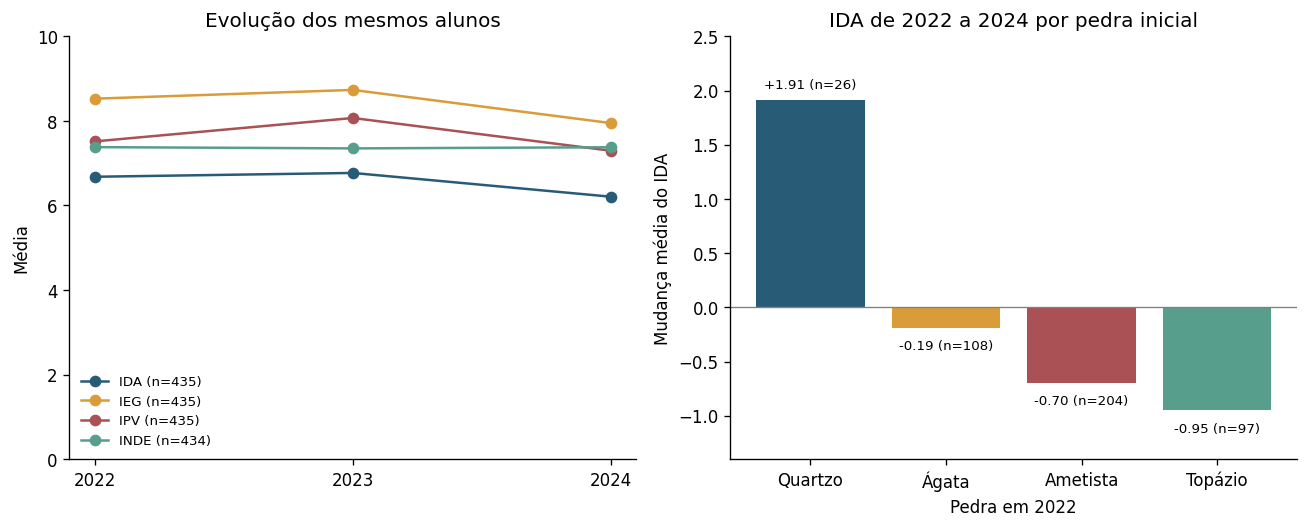

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for indicador, cor in [("IDA", CORES[0]), ("IEG", CORES[1]), ("IPV", CORES[2]), ("INDE", CORES[3])]:
    grupo = trajetorias[trajetorias.indicador.eq(indicador)]
    axes[0].plot(
        grupo["ano"],
        grupo.media,
        marker="o",
        color=cor,
        label=f"{indicador} (n={int(grupo.n.iloc[0])})",
    )
axes[0].set(xticks=ANOS, ylim=(0, 10), ylabel="Média", title="Evolução dos mesmos alunos")
axes[0].legend(frameon=False, fontsize=8, loc="lower left")
grupo = (
    mudancas_por_pedra[mudancas_por_pedra.indicador.eq("IDA")]
    .set_index("pedra_2022")
    .reindex(PEDRAS)
)
axes[1].bar(PEDRAS, grupo.delta_medio, color=CORES[:4])
axes[1].axhline(0, color="gray", linewidth=0.8)
axes[1].set(
    ylim=(-1.4, 2.5),
    ylabel="Mudança média do IDA",
    xlabel="Pedra em 2022",
    title="IDA de 2022 a 2024 por pedra inicial",
)
for i, r in enumerate(grupo.itertuples()):
    axes[1].annotate(
        f"{r.delta_medio:+.2f} (n={r.n})",
        (i, r.delta_medio),
        xytext=(0, 7 if r.delta_medio >= 0 else -13),
        textcoords="offset points",
        ha="center",
        fontsize=8,
    )
fig.tight_layout()
plt.show()
print(
    "As linhas acompanham os mesmos alunos com dados completos por indicador. As barras agrupam pela pedra de 2022; valores negativos indicam queda média de IDA até 2024."
)


**Resposta:** A melhora não é uniforme. Dos 441 alunos acompanhados, 251 melhoraram a diferença de fases, 142 mantiveram e 48 pioraram. Entre 435 com IDA completo, 233 tiveram queda superior a 0,1 ponto. O INDE médio ficou próximo de 7,38 no início e no fim. Por pedra inicial, o IDA mudou +1,91 em Quartzo (26 alunos), −0,19 em Ágata (108), −0,70 em Ametista (204) e −0,95 em Topázio (97). Quartzo, Ágata, Ametista e Topázio são categorias de INDE, não fases escolares; seus cortes variam entre anos. Há evolução observada na adequação, mas, sem grupo de comparação, não é possível confirmar impacto causal do programa.

## 11. Salvamento opcional do modelo
A aplicação já utiliza os arquivos publicados. **Executar este notebook não altera esses arquivos por padrão.** Para apenas revisar ou substituir o notebook no GitHub, mantenha `SALVAR_ARTEFATOS = False`.

Se precisar reproduzir os artefatos, altere para `True` na cópia local completa do projeto. Serão salvos os três CSVs, o pipeline e os metadados correspondentes, preservando o histórico já documentado. Os gráficos e textos publicados em `outputs/` permanecem como estão.

In [43]:
SALVAR_ARTEFATOS = False
if SALVAR_ARTEFATOS:
    if not (MODELS / "metadados_modelo.json").exists():
        raise FileNotFoundError(
            "Para atualizar os artefatos, use a pasta completa do projeto com os metadados existentes."
        )
    with (MODELS / "modelo_risco.pkl").open("rb") as arquivo:
        modelo_publicado = pickle.load(arquivo)
    assert np.allclose(
        modelo_publicado.predict_proba(X_teste), modelo_final.predict_proba(X_teste)
    ), "O modelo reproduzido diverge do publicado. Revise antes de salvar."
    colunas_app = [
        "ra",
        "ano",
        "fase",
        "pedra",
        "defasagem",
        "classe_defasagem",
        "ian",
        "ida",
        "ieg",
        "iaa",
        "ips",
        "ipp",
        "ipv",
        "inde",
    ]
    alunos_ano[colunas_app].to_csv(DATA / "alunos_ano.csv", index=False)
    dev.to_csv(DATA / "desenvolvimento.csv", index=False)
    teste.to_csv(DATA / "teste_temporal.csv", index=False)
    caminho_modelo = MODELS / "modelo_risco.pkl"
    with caminho_modelo.open("wb") as arquivo:
        pickle.dump(modelo_final, arquivo, protocol=4)
    metadados = json.loads((MODELS / "metadados_modelo.json").read_text(encoding="utf-8"))
    metadados["sha256_modelo"] = hashlib.sha256(caminho_modelo.read_bytes()).hexdigest()
    metadados["versoes"].update(
        {
            "python": platform.python_version(),
            "scikit_learn": sklearn.__version__,
            "numpy": np.__version__,
            "pandas": pd.__version__,
            "scipy": scipy.__version__,
        }
    )
    metadados["hashes_dados"] = {
        nome: hashlib.sha256((DATA / nome).read_bytes()).hexdigest()
        for nome in [
            "base_pede.xlsx",
            "alunos_ano.csv",
            "desenvolvimento.csv",
            "teste_temporal.csv",
        ]
    }
    (MODELS / "metadados_modelo.json").write_text(
        json.dumps(metadados, ensure_ascii=False, indent=2), encoding="utf-8"
    )
    print("Bases, modelo e metadados salvos. O histórico e a regra de alerta foram preservados.")
else:
    print("Execução concluída sem substituir os arquivos usados pela aplicação.")


Execução concluída sem substituir os arquivos usados pela aplicação.


## 12. Conclusão
A adequação de nível melhorou, mas o desempenho acadêmico não avançou continuamente. Os indicadores ajudam a orientar o acompanhamento, sem demonstrar impacto causal do programa.

A Regressão Logística apoia a revisão inicial de alunos sem defasagem atual. No corte de 27,8%, cerca de 64% dos alertas se confirmaram, mas quase metade dos casos não foi identificada. O acompanhamento habitual deve continuar para todos.

**Referências:** base PEDE, dicionário e pontos importantes em `data/`; [Passos Mágicos](https://passosmagicos.org.br/); [Average Precision — scikit-learn](https://scikit-learn.org/1.6/modules/generated/sklearn.metrics.average_precision_score.html).